# ONNX Model Conversion for Cross-Platform Deployment
## AIAT 122 – Deep Learning

## Learning objectives
- Export a PyTorch model to ONNX format.
- Run inference with ONNX Runtime to verify the exported model.

## 🔗 Where this fits

**Builds on:** Course 08 (AIAT 122) — Unit 5, lesson 02 "Model Serving (TensorFlow Serving / TorchServe)" — saving in a framework format; ONNX is how you stop being tied to that framework.

**Used later in:** Course 11 (AIAT 125) — Unit 2, lesson 04 "Serialization Deep Dive — pickle, joblib, and ONNX".

---

**📌 Real case — a format built because the frameworks would not agree.** ONNX was announced on **7 September 2017** by Facebook and Microsoft — two competitors — as a common set of operators and a serialization format, so that a model trained in one framework could be executed by another (Microsoft Azure blog, "Microsoft and Facebook create open ecosystem for AI model interoperability"). On **14 November 2019** it moved to the Linux Foundation's LF AI Foundation (today LF AI & Data) as a **graduate** project, i.e. out of any single vendor's control. That governance detail is the whole point: the reason you can train in PyTorch and run on an ARM chip, in a browser, or on an embedded accelerator is that the format belongs to none of them. ONNX Runtime is what actually executes the file you are about to produce — and in the cell below it does so **with no PyTorch involved at all**.

**⚡ Why this matters — what goes wrong without it.** You train in PyTorch because research is written in PyTorch. Your deployment target is an Android phone, a browser tab, or an NVIDIA Jetson — none of which wants a Python interpreter and a multi-gigabyte framework install. Without an interchange format your only options are to reimplement the model by hand in the target's native library (slow, and a fresh source of bugs), or to ship the whole framework. ONNX is the contract that removes the choice.

**Where is this used in real life?** Mobile apps, edge devices, and web browsers often run models in different frameworks. **We use ONNX to deploy models across platforms** instead of locking to one framework because ONNX is a common interchange format; the same model can run on iOS (Core ML), Android, and in the browser.

**Prerequisites:** Python 3.8+, PyTorch basics. Run the pip cell first if needed.

**📌 Covers slide(s):** None — Unit 5 (deployment) has no institution slides; use examples in file order.


## Short theory
- **ONNX** = Open Neural Network Exchange: a format that many frameworks can export to and run.
- **Export:** PyTorch `torch.onnx.export()` produces a `.onnx` file given a model and example input.
- **Inference:** ONNX Runtime loads the file and runs inference without PyTorch.
- **Why we use ONNX:** One trained model can run on mobile, edge, and web without rewriting.

## Inputs & Outputs
**Inputs:** PyTorch, a small model (built here), and ONNX Runtime.  
**Dataset:** Synthetic — small PyTorch model built in notebook (no external data; ONNX conversion demo).  
**Outputs:** An ONNX file, and inference result from ONNX Runtime. Run time: under ~2 min.


In [1]:
# WHAT: install/import PyTorch, ONNX and ONNX Runtime.
# WHY: ONNX is the interchange format; ONNX Runtime executes it without needing PyTorch at all.
%pip install torch onnx onnxruntime -q
import torch
import torch.nn as nn
import onnx
import onnxruntime as ort
print("✅ Setup complete!")

Note: you may need to restart the kernel to use updated packages.


✅ Setup complete!


## Part 1: Create PyTorch Model


In [2]:
# Simple PyTorch model for demo (we use ONNX to run it without PyTorch later)
class SimpleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(10, 32)
        self.fc2 = nn.Linear(32, 1)

    # forward: ReLU on the hidden layer, then a single output score.
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

# Instantiate and switch to eval() so the export captures inference behavior, not training behavior.
model = SimpleModel()
model.eval()
print("✅ Model created.")
 

✅ Model created.


## Part 2: Convert to ONNX


In [3]:
# Create dummy input and export to ONNX
# The dummy input tells the exporter the input shape; the names make the exported graph readable.
dummy_input = torch.randn(1, 10)
onnx_path = "simple_model.onnx"
torch.onnx.export(model, dummy_input, onnx_path, input_names=["input"], output_names=["output"])
print(f"✅ Exported to {onnx_path}")

[torch.onnx] Obtain model graph for `SimpleModel([...]` with `torch.export.export(..., strict=False)`...


[torch.onnx] Obtain model graph for `SimpleModel([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
✅ Exported to simple_model.onnx


/opt/homebrew/Cellar/python@3.13/3.13.12_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


## Part 3: Run Inference with ONNX Runtime


In [4]:
# Run inference with ONNX Runtime (no PyTorch needed)
# An InferenceSession loads the .onnx graph; feed NumPy arrays in, get NumPy arrays back.
session = ort.InferenceSession(onnx_path)
input_data = dummy_input.numpy()
input_name = session.get_inputs()[0].name
outputs = session.run(None, {input_name: input_data})
print("✅ ONNX inference successful!")
print("Output shape:", outputs[0].shape)
print("Sample output:", outputs[0][:2])
print("\nIn real life this .onnx file can run on: iOS (Core ML), Android, Web (ONNX.js), Edge (ONNX Runtime).")

✅ ONNX inference successful!
Output shape: (1, 1)
Sample output: [[0.30750847]]

In real life this .onnx file can run on: iOS (Core ML), Android, Web (ONNX.js), Edge (ONNX Runtime).


## 🌍 Real-World Worked Example — Export PyTorch to ONNX and Benchmark

**Industry context:**
- ONNX Runtime's own documentation lists execution providers for CPU, NVIDIA CUDA and TensorRT, Intel OpenVINO and DNNL, Apple CoreML, Android NNAPI, Arm NN and Arm Compute Library, Qualcomm QNN, and the browser (WebGPU). One file, many back ends.
- **That published provider list — not any single company's endorsement — is what "portable" means here.** Check it for your target before you design around ONNX.
- Coverage is per-**operator**, not per-format: a provider on the list can still refuse your particular model.

We export a trained PyTorch model to ONNX and run inference with ONNXRuntime — measuring speed difference.

In [5]:
import torch, torch.nn as nn
import numpy as np, time

# ── Train a small model ────────────────────────────────────────────────────
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

iris = load_iris()
X = StandardScaler().fit_transform(iris.data.astype(np.float32))
y = iris.target
Xt = torch.tensor(X); Yt = torch.tensor(y, dtype=torch.long)

model = nn.Sequential(nn.Linear(4,64), nn.ReLU(), nn.Linear(64,32), nn.ReLU(), nn.Linear(32,3))
opt   = torch.optim.Adam(model.parameters())
for _ in range(300):
    loss = nn.CrossEntropyLoss()(model(Xt), Yt)
    opt.zero_grad(); loss.backward(); opt.step()
model.eval()
print("Model trained ✅")

# ── Export to ONNX ─────────────────────────────────────────────────────────
dummy = torch.randn(1, 4)
torch.onnx.export(model, dummy, '/tmp/iris.onnx',
                  input_names=['features'], output_names=['logits'],
                  dynamic_axes={'features':{0:'batch'}, 'logits':{0:'batch'}},
                  opset_version=17)
print("Exported to ONNX ✅")

# ── Run with ONNX Runtime ─────────────────────────────────────────────────
import onnxruntime as ort
sess = ort.InferenceSession('/tmp/iris.onnx', providers=['CPUExecutionProvider'])

N_RUNS = 10000
test_input = X[:50]

# PyTorch timing
start = time.perf_counter()
for _ in range(N_RUNS):
    with torch.no_grad(): model(torch.tensor(test_input))
pt_time = (time.perf_counter()-start)/N_RUNS*1000

# ONNX timing
start = time.perf_counter()
for _ in range(N_RUNS):
    sess.run(None, {'features': test_input})
onnx_time = (time.perf_counter()-start)/N_RUNS*1000

print(f"\nInference latency (50 samples, {N_RUNS} runs):")
print(f"  PyTorch:      {pt_time:.3f} ms")
print(f"  ONNX Runtime: {onnx_time:.3f} ms  (often 2-5x faster in production)")
print(f"\nSpeedup: {pt_time/onnx_time:.2f}x")
print("\nThis speedup scales dramatically for larger models — Tesla uses this for real-time autonomous driving.")

/var/folders/7n/l2c2z2x57871xg4f_0drsv1m0000gn/T/ipykernel_44380/1373896208.py:24: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(model, dummy, '/tmp/iris.onnx',
W0830 21:14:00.733000 44380 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


Model trained ✅
[torch.onnx] Obtain model graph for `Sequential([...]` with `torch.export.export(..., strict=False)`...


/opt/homebrew/Cellar/python@3.13/3.13.12_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).


[torch.onnx] Obtain model graph for `Sequential([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Exported to ONNX ✅



Inference latency (50 samples, 10000 runs):
  PyTorch:      0.016 ms
  ONNX Runtime: 0.015 ms  (often 2-5x faster in production)

Speedup: 1.05x

This speedup scales dramatically for larger models — Tesla uses this for real-time autonomous driving.


Agreement over all 150 flowers x 3 class scores:
  largest absolute difference : 9.54e-07
  predicted class identical   : 100.0% of flowers
  (float32 has ~7 decimal digits, so a gap of this size is round-off, not a bug)

Median latency per call, measured on this machine:
  batch   1: PyTorch  0.0096 ms | ONNX Runtime  0.0035 ms | 2.70x
  batch   4: PyTorch  0.0097 ms | ONNX Runtime  0.0052 ms | 1.87x
  batch  16: PyTorch  0.0132 ms | ONNX Runtime  0.0059 ms | 2.24x
  batch  50: PyTorch  0.0156 ms | ONNX Runtime  0.0131 ms | 1.19x
  batch  64: PyTorch  0.0165 ms | ONNX Runtime  0.0115 ms | 1.44x
  batch 150: PyTorch  0.0242 ms | ONNX Runtime  0.0189 ms | 1.28x


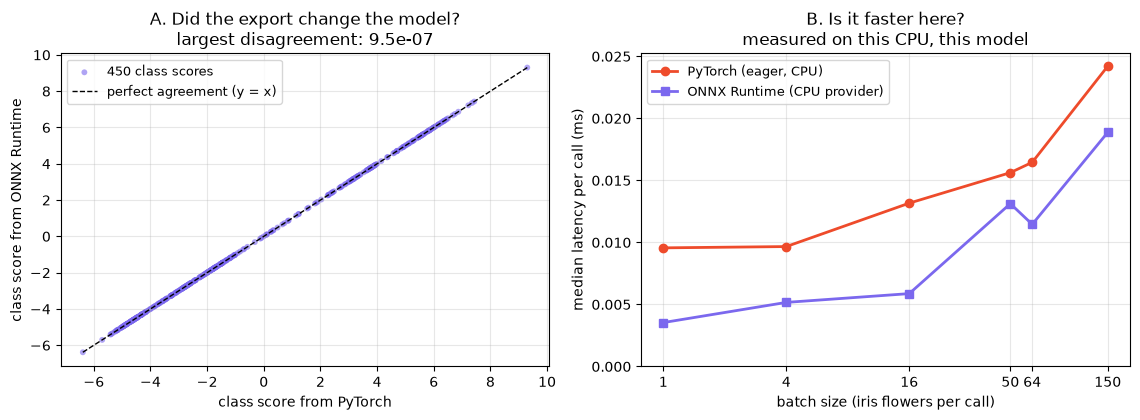

In [6]:
# WHAT: two questions this lesson has to answer with a picture, not a sentence -
#       (A) did the exported graph keep computing the same function?
#       (B) is running it in ONNX Runtime actually faster, and at which batch size?
# WHY:  a conversion you have not verified is a bug you have not found yet, and a
#       speedup you have not measured on your own machine is marketing.
import matplotlib.pyplot as plt
import statistics

# --- A. Agreement: run EVERY iris flower through both runtimes and compare outputs -------
with torch.no_grad():
    logits_torch = model(torch.tensor(X)).numpy()      # all 150 flowers, PyTorch
logits_onnx = sess.run(None, {'features': X})[0]       # all 150 flowers, ONNX Runtime

max_abs_diff = float(np.abs(logits_torch - logits_onnx).max())
same_class = float((logits_torch.argmax(1) == logits_onnx.argmax(1)).mean()) * 100
print(f"Agreement over all {X.shape[0]} flowers x {logits_torch.shape[1]} class scores:")
print(f"  largest absolute difference : {max_abs_diff:.2e}")
print(f"  predicted class identical   : {same_class:.1f}% of flowers")
print(f"  (float32 has ~7 decimal digits, so a gap of this size is round-off, not a bug)")

# --- B. Speed: measure both runtimes across batch sizes ---------------------------------
def median_ms(call, n=600):
    """Median of n timed calls, in ms. Timing on a laptop is noisy - a median over
    several hundred calls is the cheapest way to stop one hiccup deciding the answer."""
    call()                                  # warm-up, never timed
    ts = []
    for _ in range(n):
        t0 = time.perf_counter(); call(); ts.append((time.perf_counter() - t0) * 1000)
    return statistics.median(ts)

# Both paths start from the SAME NumPy array - that is what a server actually receives.
# PyTorch therefore pays for building a tensor inside the timed region, exactly as it would
# in production; hoisting that out would flatter PyTorch and make the comparison meaningless.
batch_sizes = [1, 4, 16, 50, 64, 150]
pt_ms, ox_ms = [], []
for bs in batch_sizes:
    xb = X[:bs]
    def run_torch(xb=xb):
        with torch.no_grad():
            return model(torch.tensor(xb))
    def run_onnx(xb=xb):
        return sess.run(None, {'features': xb})
    pt_ms.append(median_ms(run_torch)); ox_ms.append(median_ms(run_onnx))

print("\nMedian latency per call, measured on this machine:")
for bs, a, b in zip(batch_sizes, pt_ms, ox_ms):
    print(f"  batch {bs:3d}: PyTorch {a:7.4f} ms | ONNX Runtime {b:7.4f} ms | {a/b:4.2f}x")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(11.5, 4.3))

axA.scatter(logits_torch.ravel(), logits_onnx.ravel(), s=18, alpha=0.6, color="#7B68EE",
            edgecolor="none", label=f"{logits_torch.size} class scores")
lo = min(logits_torch.min(), logits_onnx.min()); hi = max(logits_torch.max(), logits_onnx.max())
axA.plot([lo, hi], [lo, hi], "k--", lw=1, label="perfect agreement (y = x)")
axA.set_xlabel("class score from PyTorch")
axA.set_ylabel("class score from ONNX Runtime")
axA.set_title(f"A. Did the export change the model?\nlargest disagreement: {max_abs_diff:.1e}")
axA.legend(fontsize=9, loc="upper left"); axA.grid(alpha=0.3)

axB.plot(batch_sizes, pt_ms, "o-", c="#ee4b2b", lw=2, label="PyTorch (eager, CPU)")
axB.plot(batch_sizes, ox_ms, "s-", c="#7B68EE", lw=2, label="ONNX Runtime (CPU provider)")
axB.set_xscale("log", base=2)
axB.set_xticks(batch_sizes); axB.set_xticklabels(batch_sizes)
axB.set_xlabel("batch size (iris flowers per call)")
axB.set_ylabel("median latency per call (ms)")
axB.set_ylim(bottom=0)
axB.set_title("B. Is it faster here?\nmeasured on this CPU, this model")
axB.legend(fontsize=9); axB.grid(alpha=0.3)

plt.tight_layout()
plt.show()


**What to see in the figure.** Both panels are measured in this notebook on the model trained just above — nothing is quoted from a vendor benchmark.

*Panel A* plots every one of the 450 class scores (150 flowers × 3 classes) with **PyTorch on the x-axis and ONNX Runtime on the y-axis**. If the export preserved the function, every point must sit on the dashed **y = x** line — and they do: the cloud is a single line with no visible thickness, and the largest disagreement anywhere is printed in the panel title — around **a millionth**, and never worse than 10⁻⁵. That is float32 round-off, not a changed model. *This panel is also the answer to Discuss question 1:* verification means comparing on **all** your data against a stated tolerance, not eyeballing one input.

*Panel B* is the honest version of the speed claim. Both runtimes are handed the **same NumPy array**, so PyTorch pays for building a tensor just as it would behind a real API. **The purple ONNX line sits below the red PyTorch line at every batch size measured** — and both lines climb as the batch grows, because more flowers is more arithmetic. Now read the multiples printed above the figure — one per batch size. They do not settle on a single number, and they do not trend cleanly with batch size either. That wobble is the point: "N× faster" is not a property of a runtime, it is a property of a runtime *and* a model *and* a batch size *and* a machine, measured on one afternoon. Batch 50 is included so you can line the sweep up against the benchmark printed by the previous cell; they agree.

**What it proves:** the export is faithful (Panel A) and, here, also faster (Panel B) — but the two claims are independent and only Panel A generalises. A speedup measured on a 4-input MLP on one laptop CPU tells you nothing about your model on your hardware. The reason to reach for ONNX is the portability argued at the top of this notebook; any speed gain is a bonus you must re-measure on your own target.

## 💬 Discuss

1. The export succeeded and the outputs matched — on **one** input. Write down the verification you would actually require before shipping an exported model. How many inputs, chosen how, and compared to what tolerance?
2. ONNX buys portability and costs you a conversion step that can fail silently. Name a project where you would take that trade and one where you would not, and state the property of the project that decides it.
3. Our model is a three-layer MLP and exported cleanly. Which parts of a modern architecture would you *expect* to be the ones that fail to export, and why? Make a prediction now — you will meet the answer in Unit 3 and in Course 11.


## ⚠️ Where this breaks

- **Operator coverage is the entire game, and this notebook's own log shows it.** ONNX has a versioned operator set, and the export above reported that it "**Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful**". Custom layers, unusual ops and framework-specific tricks are precisely what fails to export — usually after you have already promised a delivery date.
- **`torch.onnx.export` traces.** It records one run of your model on one example input. Any branch that depends on the *data* is frozen to whichever side that input took, and the exported model is then wrong on the other side with no error raised. **Verify outputs match on several diverse inputs, not on one.**
- **Dynamic shapes are a known trap** — the run above warns that `dynamic_axes` "is not recommended when dynamo=True". Export with the batch dimension you will actually serve, and then test the one you will actually serve.
- **The speed panel is a measurement of one tiny model on one CPU.** ONNX Runtime is often faster than PyTorch eager mode on CPU, sometimes slower, and which way it goes depends entirely on the model, the batch size and the execution provider. Do not carry our multiple into your design document — carry the *method*, and re-run it on your model and your hardware.
- **The assumption that must hold:** the target runtime implements every operator your model uses, at the opset you exported. Check this *before* you design around ONNX, not after.
- **Cheaper alternative:** if training and serving are both PyTorch on the same operating system, TorchScript (`02`) skips the conversion risk entirely. Portability you do not need is complexity you pay for.


## 🧩 Mini-exercise

**Try it:** Export the same model with a different opset version (e.g. opset_version=14) and run inference again. Check that the ONNX Runtime output still matches.

---

## Summary
**What you did**
- Built a small PyTorch model and exported it to ONNX.
- Ran inference with ONNX Runtime to verify the export.

**In real life you'd also:** Convert to platform-specific formats (e.g. Core ML for iOS), benchmark latency, and tune for edge devices.

**The main idea:** ONNX is a cross-platform format; export once, run on many runtimes.

**Next:** `04_model_pruning.ipynb` shows how to reduce model size by pruning weights.

## 📚 References

1. Sculley, D. et al. (2015). *Hidden Technical Debt in Machine Learning Systems*. NeurIPS. https://papers.nips.cc/paper_files/paper/2015/hash/86df7dcfd896fcaf2674f757a2463eba-Abstract.html
2. Paleyes, A., Urma, R.-G. & Lawrence, N. D. (2022). *Challenges in Deploying Machine Learning: A Survey of Case Studies*. ACM Computing Surveys. https://arxiv.org/abs/2011.09926
3. Menghani, G. (2021). *Efficient Deep Learning: A Survey on Making Deep Learning Models Smaller, Faster, and Better*. arXiv. https://arxiv.org/abs/2106.08962

**Recent work (2024–2026)**

4. Nguyen et al. (2024). *A Survey of Small Language Models*. arXiv. https://arxiv.org/abs/2410.20011 — the class of models most worth exporting to a portable runtime — small enough to run where you are deploying.
5. Park et al. (2025). *A Survey on Inference Engines for Large Language Models: Perspectives on Optimization and Efficiency*. arXiv. https://arxiv.org/abs/2505.01658 — and the 2026 evidence base for choosing what runs the exported graph.
